In [1]:
import os

# uncomment to disable NVIDIA GPUs
#os.environ['CUDA_VISIBLE_DEVICES'] = ''
# or pick the device (cpu, gpu, and tpu)
#os.environ['JAX_PLATFORMS'] = 'cpu'

# change JAX GPU memory preallocation fraction
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.95'

# you do not want this
#os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true'

import jax
jax.print_environment_info()

# !nvidia-smi --query-gpu=gpu_name --format=csv,noheader

jax:    0.4.26
jaxlib: 0.4.26
numpy:  1.26.4
python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
jax.devices (1 total, 1 local): [cuda(id=0)]
process_count: 1
platform: uname_result(system='Linux', node='r903u37n01.grace.ycrc.yale.edu', release='4.18.0-477.75.1.el8_8.x86_64', version='#1 SMP Mon Sep 30 16:14:54 EDT 2024', machine='x86_64')


$ nvidia-smi
Fri Jan 10 09:00:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.06              Driver Version: 555.42.06      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|========================

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rc("text", usetex=True)
plt.rc("font", **{"family": "DejaVu Sans", "size": 20})
plt.rc("axes", labelsize=16)
plt.rc("xtick", labelsize=16)
plt.rc("ytick", labelsize=16)

from cycler import cycler
from matplotlib import cm
from matplotlib import colors as mc
from matplotlib.colors import LogNorm, PowerNorm
from matplotlib.collections import PolyCollection
from mpl_toolkits.mplot3d import Axes3D

from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches

%matplotlib inline
# %matplotlib widget

In [3]:
from pmwd import (Configuration, Cosmology, SimpleLCDM, 
                    particles, boltzmann, linear_power, growth, 
                    white_noise, linear_modes, 
                    lpt, nbody, scatter)

from pmwd.vis_util import simshow

import readgadget
import readfof
import redshift_space_library as RSL
import MAS_library as MASL
import smoothing_library as SL
import Pk_library as PKL
import cosmology_library as CL

import numpy as np
import pandas as pd

In [20]:
BoxSize = 1000.0
grid    = 128

if jax.default_backend() == 'gpu':
    ptcl_spacing = BoxSize/grid  # Lagrangian space Cartesian particle grid spacing, in Mpc/h by default
    ptcl_grid_shape = (grid,) * 3
else:
    ptcl_spacing = BoxSize/64
    ptcl_grid_shape = (64,) * 3

conf = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=1)  # 1x mesh shape
print(conf)  # with other default parameters

Configuration(ptcl_spacing=7.8125,
              ptcl_grid_shape=(128, 128, 128),
              mesh_shape=(128, 128, 128),
              cosmo_dtype=dtype('float64'),
              pmid_dtype=dtype('int16'),
              float_dtype=dtype('float32'),
              k_pivot_Mpc=0.05,
              T_cmb=2.7255,
              M=1.98847e+40,
              L=3.0856775815e+22,
              T=3.0856775815e+17,
              transfer_fit=True,
              transfer_fit_nowiggle=False,
              transfer_lgk_min=-4,
              transfer_lgk_max=3,
              transfer_lgk_maxstep=0.0078125,
              growth_rtol=1.4901161193847656e-08,
              growth_atol=1.4901161193847656e-08,
              growth_inistep=(1, None),
              lpt_order=2,
              a_start=0.015625,
              a_stop=1,
              a_lpt_maxstep=0.0078125,
              a_nbody_maxstep=0.015625,
              symp_splits=((0, 0.5), (1, 0.5)),
              chunk_size=16777216)


In [21]:
conf.box_size

(1000.0, 1000.0, 1000.0)

In [22]:
print(f'Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps.')

Simulating 2097152 particles with a (128, 128, 128) mesh for 63 time steps.


In [23]:
# Quijote cosmology 
cosmo = Cosmology(conf, A_s_1e9=2.0, n_s=0.9624, Omega_m=0.3175, Omega_b=0.049, h=0.6711)
# or simply use the predefined SimpleLCDM
#cosmo = SimpleLCDM(conf)

print(cosmo)

Cosmology(A_s_1e9=Array(2., dtype=float64),
          n_s=Array(0.962, dtype=float64),
          Omega_m=Array(0.318, dtype=float64),
          Omega_b=Array(0.049, dtype=float64),
          h=Array(0.671, dtype=float64),
          Omega_k_=None,
          w_0_=None,
          w_a_=None,
          transfer=None,
          growth=None,
          varlin=None)


In [24]:
%time cosmo = jax.block_until_ready(boltzmann(cosmo, conf))
%timeit jax.block_until_ready(boltzmann(cosmo, conf))

CPU times: user 1.04 s, sys: 36.2 ms, total: 1.07 s
Wall time: 1.56 s
16.6 ms ± 177 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [25]:
seed  = 1
modes = white_noise(seed, conf)
modes = linear_modes(modes, cosmo, conf)

In [26]:
# Solve LPT at some early time:

%time ptcl, obsvbl = jax.block_until_ready(lpt(modes, cosmo, conf))
%timeit jax.block_until_ready(lpt(modes, cosmo, conf))

ptcl.disp.std()

CPU times: user 575 ms, sys: 12.6 ms, total: 588 ms
Wall time: 1.06 s
4.01 ms ± 5.5 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Array(0.112, dtype=float32)

In [27]:
# Finally, N-body time integration from the LPT initial conditions:

%time jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))
%time ptcl, obsvbl = jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))

ptcl.disp.std()

CPU times: user 1.59 s, sys: 137 ms, total: 1.73 s
Wall time: 2.1 s
CPU times: user 119 ms, sys: 59.7 ms, total: 179 ms
Wall time: 205 ms


Array(4.972, dtype=float32)

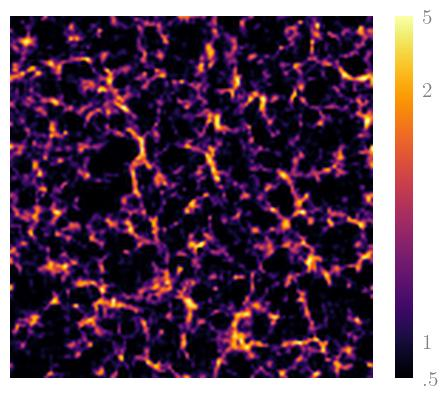

In [28]:
dens = scatter(ptcl, conf)
simshow(dens[:16].mean(axis=0), norm='CosmicWebNorm');

In [29]:
seed  = 123
# cosmo = SimpleLCDM(conf)
cosmo = Cosmology(conf, A_s_1e9=2.0, n_s=0.9624, Omega_m=0.3175, Omega_b=0.049, h=0.6711)
modes = white_noise(seed, conf)

def model(modes, cosmo, conf):
    cosmo = boltzmann(cosmo, conf)
    modes = linear_modes(modes, cosmo, conf)
    ptcl, obsvbl = lpt(modes, cosmo, conf)
    ptcl, obsvbl = nbody(ptcl, obsvbl, cosmo, conf)
    return ptcl, obsvbl

print(f'Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps.')
%time ptcl, obsvbl = jax.block_until_ready(model(modes, cosmo, conf));

Simulating 2097152 particles with a (128, 128, 128) mesh for 63 time steps.
CPU times: user 152 ms, sys: 54.8 ms, total: 207 ms
Wall time: 238 ms


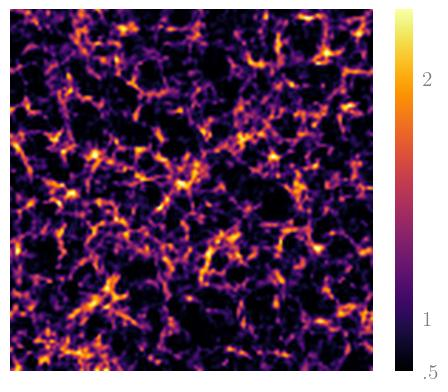

In [30]:
dens = scatter(ptcl, conf)
simshow(dens[:16].mean(axis=0), norm='CosmicWebNorm');

In [31]:
ptcl.disp

Array([[-8.704, -4.12 ,  1.135],
       [-7.828, -4.055, -2.86 ],
       ...,
       [-4.565,  0.53 , 11.039],
       [-7.486, -0.358,  6.538]], dtype=float32)

In [32]:
ptcl.pmid

Array([[  0,   0,   0],
       [  0,   0,   1],
       ...,
       [127, 127, 126],
       [127, 127, 127]], dtype=int16)

In [33]:
nsim = 1
print('HADES - Simulation %s'%nsim, flush=True)

snapshot = '/home/fn234/gibbs/DATA/HADES/SIMS/%s/snapdir_004/snap_004'%(nsim)
ptype    = [1]

header   = readgadget.header(snapshot)
BoxSize  = header.boxsize/1e3  #Mpc/h
Nall     = header.nall[ptype]         #Total number of particles
Masses   = header.massarr[ptype]*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
Omega_l  = header.omega_l      #value of Omega_l
h        = header.hubble       #value of h
redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)

# read positions, velocities and IDs of the particles
pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
ids = readgadget.read_block(snapshot, "ID  ", ptype)-1   #IDs starting from 0

indexes = np.argsort(ids)
pos     = pos[indexes]
del ids

HADES - Simulation 1


In [34]:
ics = '/home/fn234/gibbs/DATA/HADES/SIMS/%s/ICs/ics'%(nsim)
ptype    = [1]

header_ic   = readgadget.header(ics)
redshift_ic = header_ic.redshift     #redshift of the initial condition

# read positions, velocities and IDs of the particles
pos_ic = readgadget.read_block(ics, "POS ", ptype)/1e3 #positions in Mpc/h
vel_ic = readgadget.read_block(ics, "VEL ", ptype)     #peculiar velocities in km/s
ids_ic = readgadget.read_block(ics, "ID  ", ptype)-1   #IDs starting from 0

indexes = np.argsort(ids_ic)
pos_ic  = pos_ic[indexes]
vel_ic  = vel_ic[indexes]
del ids_ic

In [36]:
grid       = 512
grid_index = (np.round((pos_ic/BoxSize)*grid, decimals=0)).astype(np.int32)
grid_index[np.where(grid_index==grid)]=0

pos_grid   = grid_index*BoxSize/grid

disp_true = pos - pos_ic
# take into account periodic boundary conditions
disp_true[np.where(disp_true>BoxSize/2.0)]  -= BoxSize
disp_true[np.where(disp_true<-BoxSize/2.0)] += BoxSize

disp_true.std()

5.808355

In [37]:
grid    = 128    #the 3D field will have grid x grid x grid voxels
MAS     = 'CIC'  #mass-assigment scheme
verbose = True   #print information on progress
axis      = 0
threads   = 20

rho_ic = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_ic, rho_ic, BoxSize, MAS, verbose=verbose)

disp_trueX = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_ic, disp_trueX, BoxSize, MAS, W=disp_true[:, 0])
disp_trueX /= rho_ic

disp_trueY = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_ic, disp_trueY, BoxSize, MAS, W=disp_true[:, 1])
disp_trueY /= rho_ic

disp_trueZ = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_ic, disp_trueZ, BoxSize, MAS, W=disp_true[:, 2])
disp_trueZ /= rho_ic


Using CIC mass assignment scheme
Time taken = 3.932 seconds



In [38]:
grid_x, grid_y, grid_z = np.meshgrid(np.arange(grid), np.arange(grid), np.arange(grid), indexing='ij')
grid_indices = np.stack((grid_x, grid_y, grid_z), axis=-1).reshape(-1, 3)

In [43]:
disp_true128 = np.c_[disp_trueX[grid_indices[:, 0], grid_indices[:, 1], grid_indices[:, 2]], 
                     disp_trueY[grid_indices[:, 0], grid_indices[:, 1], grid_indices[:, 2]],
                     disp_trueZ[grid_indices[:, 0], grid_indices[:, 1], grid_indices[:, 2]]]

In [56]:
indexes   = np.lexsort(grid_index.T[::-1])
disp_true = disp_true[indexes]

In [21]:
# idx1 = np.lexsort(grid_index.T[::-1])
# idx2 = np.lexsort(ptcl.pmid.T[::-1])

# np.all(grid_index[idx1] == ptcl.pmid[idx2]) #Array(True, dtype=bool)

# grid_index = grid_index[idx1]
# disp_true = disp_true[idx1]

In [47]:
disp_true128

array([[ 2.804, -4.428, -1.329],
       [ 5.615, -3.812, -2.377],
       ...,
       [ 1.206, -4.843,  4.287],
       [ 0.435, -6.894,  3.347]], dtype=float32)

In [48]:
ptcl.disp

Array([[-8.704, -4.12 ,  1.135],
       [-7.828, -4.055, -2.86 ],
       ...,
       [-4.565,  0.53 , 11.039],
       [-7.486, -0.358,  6.538]], dtype=float32)

In [50]:
(ptcl.disp - disp_true128).var()

Array(52.91, dtype=float32)

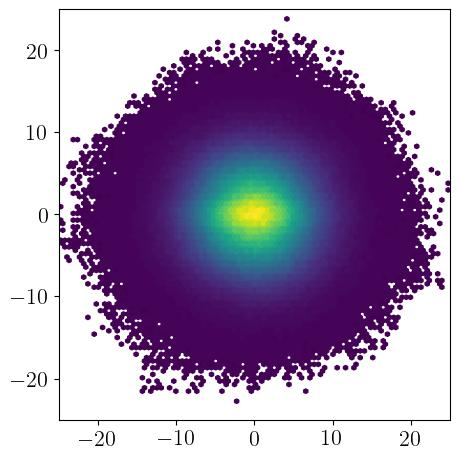

In [53]:
plt.figure(figsize=(5, 5))
plt.hexbin(disp_true128[:, 0], ptcl.disp[:, 0], bins=100, mincnt=1);
plt.xlim(-25, 25)
plt.ylim(-25, 25)
plt.tight_layout()

# Differentiating over modes and cosmological parameters 

In [54]:
seed = 1  # change the seed for a different realization, to be compared to the previous one in the objective
modes = white_noise(seed, conf, real=True)  # this time we want real modes to look at their gradients

In [56]:
def obj(tgt_disp, modes, cosmo, conf):
    cosmo = boltzmann(cosmo, conf)
    modes = linear_modes(modes, cosmo, conf)
    ptcl, obsvbl = lpt(modes, cosmo, conf)
    ptcl, obsvbl = nbody(ptcl, obsvbl, cosmo, conf)
    return (ptcl.disp - tgt_disp).var()

obj_grad = jax.grad(obj, argnums=(1, 2))

print(f'Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps, '
      'and then differentiating backward.')
%time jax.block_until_ready(obj_grad(disp_true128, modes, cosmo, conf))
%time modes_grad, cosmo_grad = jax.block_until_ready(obj_grad(disp_true128, modes, cosmo, conf))

Simulating 2097152 particles with a (128, 128, 128) mesh for 63 time steps, and then differentiating backward.
CPU times: user 9.31 s, sys: 581 ms, total: 9.89 s
Wall time: 14.4 s
CPU times: user 618 ms, sys: 230 ms, total: 848 ms
Wall time: 929 ms


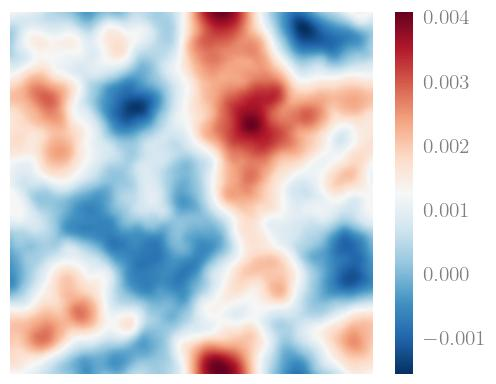

In [57]:
simshow(modes_grad[..., 0], cmap='RdBu_r');

In [58]:
print(cosmo_grad)

Cosmology(A_s_1e9=Array(12.338, dtype=float64),
          n_s=Array(-16.721, dtype=float64),
          Omega_m=Array(56.221, dtype=float64),
          Omega_b=Array(-146.447, dtype=float64),
          h=Array(51.01, dtype=float64),
          Omega_k_=None,
          w_0_=None,
          w_a_=None,
          transfer=None,
          growth=None,
          varlin=None)


In [59]:
from jax.example_libraries.optimizers import adam
import jax.numpy as jnp

In [60]:
def model(modes, cosmo, conf):
    modes = linear_modes(modes, cosmo, conf)
    ptcl, obsvbl = lpt(modes, cosmo, conf)
    ptcl, obsvbl = nbody(ptcl, obsvbl, cosmo, conf)
    return ptcl.disp

In [61]:
def obj(tgt_disp, modes, cosmo, conf):
    disp = model(modes, cosmo, conf)
    return (disp - tgt_disp).var() / tgt_disp.var()

In [66]:
obj_valgrad = jax.value_and_grad(obj, argnums=1)

In [77]:
def optim(tgt_disp, modes, cosmo, conf, iters=100, lr=0.1):
    init, update, get_params = adam(lr)
    state = init(modes)

    def step(i, state, tgt_disp, cosmo, conf):
        modes = get_params(state)
        value, grads = obj_valgrad(tgt_disp, modes, cosmo, conf)
        state = update(i, grads, state)
        return value, state

    tgt_disp = jnp.asarray(tgt_disp)
    for i in range(iters):
        value, state = step(i, state, tgt_disp, cosmo, conf)

    modes = get_params(state)
    return value, modes

In [80]:
conf = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=1)
# cosmo = SimpleLCDM(conf)
cosmo = Cosmology(conf, A_s_1e9=2.0, n_s=0.9624, Omega_m=0.3175, Omega_b=0.049, h=0.6711)
seed = 1
modes = white_noise(seed, conf, real=True)
cosmo = boltzmann(cosmo, conf)

In [81]:
loss, modes_optim = optim(disp_true128, modes, cosmo, conf, iters=100)
loss, modes.std(), modes_optim.std()

(Array(0.257, dtype=float32),
 Array(1., dtype=float32),
 Array(0.995, dtype=float32))

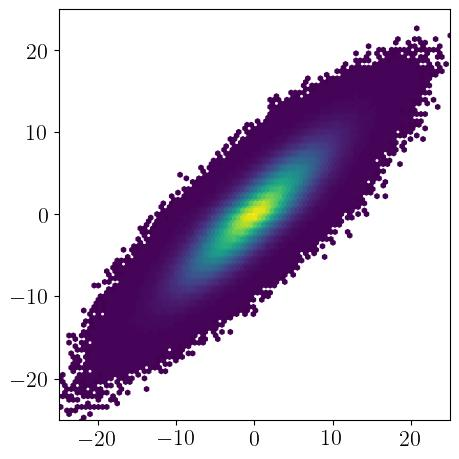

In [82]:
disp_optim = model(modes_optim, cosmo, conf)

plt.figure(figsize=(5, 5))
plt.hexbin(disp_true128[:, 0], disp_optim[:, 0], bins=100, mincnt=1);
plt.xlim(-25, 25)
plt.ylim(-25, 25)
plt.tight_layout()

In [83]:
loss, modes_optim = optim(disp_true128, modes, cosmo, conf, iters=1000)
loss, modes.std(), modes_optim.std()

(Array(0.086, dtype=float32),
 Array(1., dtype=float32),
 Array(0.998, dtype=float32))

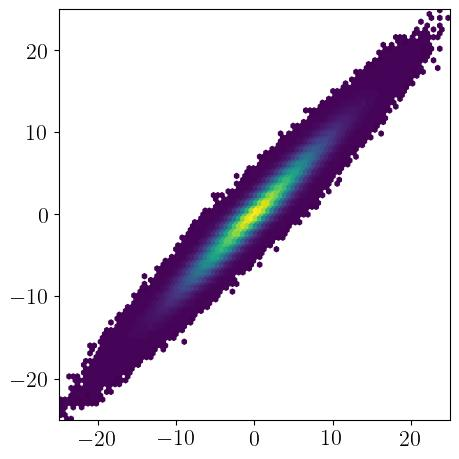

In [84]:
disp_optim = model(modes_optim, cosmo, conf)

plt.figure(figsize=(5, 5))
plt.hexbin(disp_true128[:, 0], disp_optim[:, 0], bins=100, mincnt=1);
plt.xlim(-25, 25)
plt.ylim(-25, 25)
plt.tight_layout()

In [1]:
pwd

'/gpfs/gibbs/project/padmanabhan/fn234/FLI'